In [2]:
import joblib
import glob
import os
from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# =====================================================================
# CONFIGURASI DIREKTORI, TIMESTAMP & FILE EVALUASI
# =====================================================================
waktu_sekarang = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Timestamp evaluasi saat ini: {waktu_sekarang}")

LABEL_COL = "label"

# Rute Direktori Dinamis yang tersinkronisasi dengan ekstraktor
INPUT_DIR = Path("hasil_ekstraksi")
MODEL_DIR = Path("output/models")
GRAPH_OUT_DIR = Path("output/grafik")
GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_OUT_DIR = Path("output/metrik")
METRIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Berkas Induk Data Uji Murni (Baseline)
BASELINE_TEST_CSV = "fitur_test_set.csv"

# Mapping 4 Teknik Obfuskasi Data Uji (Sesuai dengan Output Ekstraktor Terbaru)
TEST_FILES = {
    "Data Asli (Baseline)" : "fitur_test_set.csv",
    "ASCII Encoding"       : "fitur_test_set_obf_ASCII_Encoding.csv",
    "String Concatenation" : "fitur_test_set_obf_String_Concatenation.csv",
    "String Reordering"    : "fitur_test_set_obf_String_Reordering.csv",
    "Token Manipulation"   : "fitur_test_set_obf_Token_Manipulation.csv"
}

print("✅ [CELL 0] Pustaka, Direktori Dinamis, dan Mapping Data Uji Berhasil Dimuat.")

Timestamp evaluasi saat ini: 20260713_084059
✅ [CELL 0] Pustaka, Direktori Dinamis, dan Mapping Data Uji Berhasil Dimuat.


In [3]:
def _plot_combined_confusion_matrix(scenario_label: str, models_data: dict, timestamp: str) -> None:
    """Mengonstruksi grid Confusion Matrix untuk seluruh model dalam satu skenario."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    fig.suptitle(f"Confusion Matrix: {scenario_label}", fontsize=18, fontweight='bold', y=0.97)
    
    axes = axes.flatten()
    for idx, (model_name, m_data) in enumerate(models_data.items()):
        cm = m_data['cm']
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False,
                    xticklabels=["Benign", "Malicious"],
                    yticklabels=["Benign", "Malicious"],
                    annot_kws={"size": 14})
        axes[idx].set_title(model_name, fontsize=14, fontweight='bold')
        axes[idx].set_xlabel("Predicted Label", fontsize=12)
        axes[idx].set_ylabel("True Label", fontsize=12)
        
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    # Ekspor Grafik Otomatis
    safe_label = scenario_label.replace(' ', '_').replace('(', '').replace(')', '')
    file_path = GRAPH_OUT_DIR / f"cm_{safe_label}_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"      -> Confusion Matrix disimpan di: {file_path.name}")

# =====================================================================
# FUNGSI VISUALISASI KURVA BERORIENTASI LANDSCAPE
# =====================================================================

def _plot_roc_curves_landscape_grid(plot_data_registry: dict, timestamp: str) -> None:
    """Mengonstruksi Kelompok Kurva ROC dalam format Grid Landscape."""
    scenarios = list(plot_data_registry.keys())
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 11))
    axes = axes.flatten()
    
    for idx, scenario_label in enumerate(scenarios):
        ax_roc = axes[idx]
        models_data = plot_data_registry[scenario_label]
        
        for model_name, m_data in models_data.items():
            y_true = m_data['y_true']
            y_proba = m_data['y_proba']
            
            if np.sum(y_true) > 0 and len(np.unique(y_true)) > 1:
                fpr, tpr, _ = roc_curve(y_true, y_proba)
                roc_auc = auc(fpr, tpr)
                ax_roc.plot(fpr, tpr, lw=2.5, label=f"{model_name} (AUC = {roc_auc:.4f})")
        
        ax_roc.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=10)
        ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=10)
        ax_roc.set_title(f'{scenario_label}', fontsize=12, fontweight='bold', pad=8)
        ax_roc.legend(loc="lower right", fontsize=9)
        ax_roc.grid(True, linestyle='--', alpha=0.5)
        
    if len(scenarios) < len(axes):
        for empty_idx in range(len(scenarios), len(axes)):
            fig.delaxes(axes[empty_idx])
            
    fig.suptitle('Kurva Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    file_path = GRAPH_OUT_DIR / f"roc_curve_all_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"▶ [LANDSCAPE] Grup Visualisasi Kurva ROC Berhasil Di-render & Disimpan: {file_path.name}")


def _plot_pr_curves_landscape_grid(plot_data_registry: dict, timestamp: str) -> None:
    """Mengonstruksi Kelompok Kurva Precision-Recall (PR) dalam format Grid Landscape."""
    scenarios = list(plot_data_registry.keys())
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 11))
    axes = axes.flatten()
    
    for idx, scenario_label in enumerate(scenarios):
        ax_pr = axes[idx]
        models_data = plot_data_registry[scenario_label]
        
        for model_name, m_data in models_data.items():
            y_true = m_data['y_true']
            y_proba = m_data['y_proba']
            
            if np.sum(y_true) > 0 and len(np.unique(y_true)) > 1:
                precision, recall, _ = precision_recall_curve(y_true, y_proba)
                pr_auc = average_precision_score(y_true, y_proba)
                ax_pr.plot(recall, precision, lw=2.5, label=f"{model_name} (PR AUC = {pr_auc:.4f})")
        
        first_model_key = list(models_data.keys())[0]
        baseline_ratio = np.sum(models_data[first_model_key]['y_true']) / len(models_data[first_model_key]['y_true'])
        
        ax_pr.plot([0, 1], [baseline_ratio, baseline_ratio], color='black', lw=1.5, linestyle='--', label=f'Baseline ({baseline_ratio:.2f})')
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall', fontsize=10)
        ax_pr.set_ylabel('Precision', fontsize=10)
        ax_pr.set_title(f'{scenario_label}', fontsize=12, fontweight='bold', pad=8)
        ax_pr.legend(loc="lower left", fontsize=9)
        ax_pr.grid(True, linestyle='--', alpha=0.5)
        
    if len(scenarios) < len(axes):
        for empty_idx in range(len(scenarios), len(axes)):
            fig.delaxes(axes[empty_idx])
            
    fig.suptitle('Kurva Precision-Recall (PR)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    file_path = GRAPH_OUT_DIR / f"pr_curve_all_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"▶ [LANDSCAPE] Grup Visualisasi Kurva PR Berhasil Di-render & Disimpan: {file_path.name}")

print("✅ [CELL 1] Skrip Pemformat Visualisasi Auto-Save Berhasil Dimuat.")

✅ [CELL 1] Skrip Pemformat Visualisasi Auto-Save Berhasil Dimuat.


In [4]:
def _print_comparison_table_formatted(result_rows: list, timestamp: str) -> None:
    """Mencetak laporan perbandingan metrik kinerja semua model ke bentuk tabel teks formal."""
    df_results = pd.DataFrame(result_rows)
    print("\n" + "="*145)
    print(f"{'TABEL KOMPARASI EVALUASI METRIK DETEKSI (BASELINE VS AUGMENTASI)':^145}")
    print("="*145)
    
    # Ekspor tabel log ke CSV sebelum diubah jadi string
    out_csv = METRIC_OUT_DIR / f"evaluasi_test_set_{timestamp}.csv"
    df_results.to_csv(out_csv, index=False)
    
    # [DIPERBARUI]: Menambahkan 'FPR' dan 'FNR' agar diformat 4 angka di belakang koma
    float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR', 'FNR', 'ROC AUC', 'PR AUC']
    for col in float_cols:
        if col in df_results.columns:
            df_results[col] = df_results[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)
            
    print(df_results.to_string(index=False))
    print("="*145)
    print(f"✅ Tabel hasil evaluasi komprehensif berhasil diekspor secara permanen ke: {out_csv.name}\n")

print("✅ [CELL 2] Skrip Pemformat Tabel Metrik dan Ekspor CSV Berhasil Dimuat.")

✅ [CELL 2] Skrip Pemformat Tabel Metrik dan Ekspor CSV Berhasil Dimuat.


▶ MULAI EKSEKUSI PIPELINE EVALUASI: 2026-07-13 08:40:59
[*] Memuat seluruh model .joblib terbaru dari direktori output...
    - Berhasil memuat: RF (Baseline)
    - Berhasil memuat: RF (Augmentasi)
    - Berhasil memuat: XGB (Baseline)
    - Berhasil memuat: XGB (Augmentasi)
    - Berhasil memuat: LGBM (Baseline)
    - Berhasil memuat: LGBM (Augmentasi)
✅ Sukses memuat 6 arsitektur model untuk dievaluasi.

[*] Menjalankan Pengujian Komparatif Lintas Skenario Teknik...

                                        TABEL KOMPARASI EVALUASI METRIK DETEKSI (BASELINE VS AUGMENTASI)                                         
        Skenario Uji    Model-Skenario Accuracy Precision Recall F1-Score    FPR    FNR ROC AUC PR AUC
Data Asli (Baseline)     RF (Baseline)   0.9766    0.9943 0.9284   0.9602 0.0023 0.0716  0.9943 0.9915
Data Asli (Baseline)   RF (Augmentasi)   0.9774    0.9972 0.9284   0.9615 0.0012 0.0716  0.9947 0.9922
Data Asli (Baseline)    XGB (Baseline)   0.9822    0.9944 0.9469   0.97

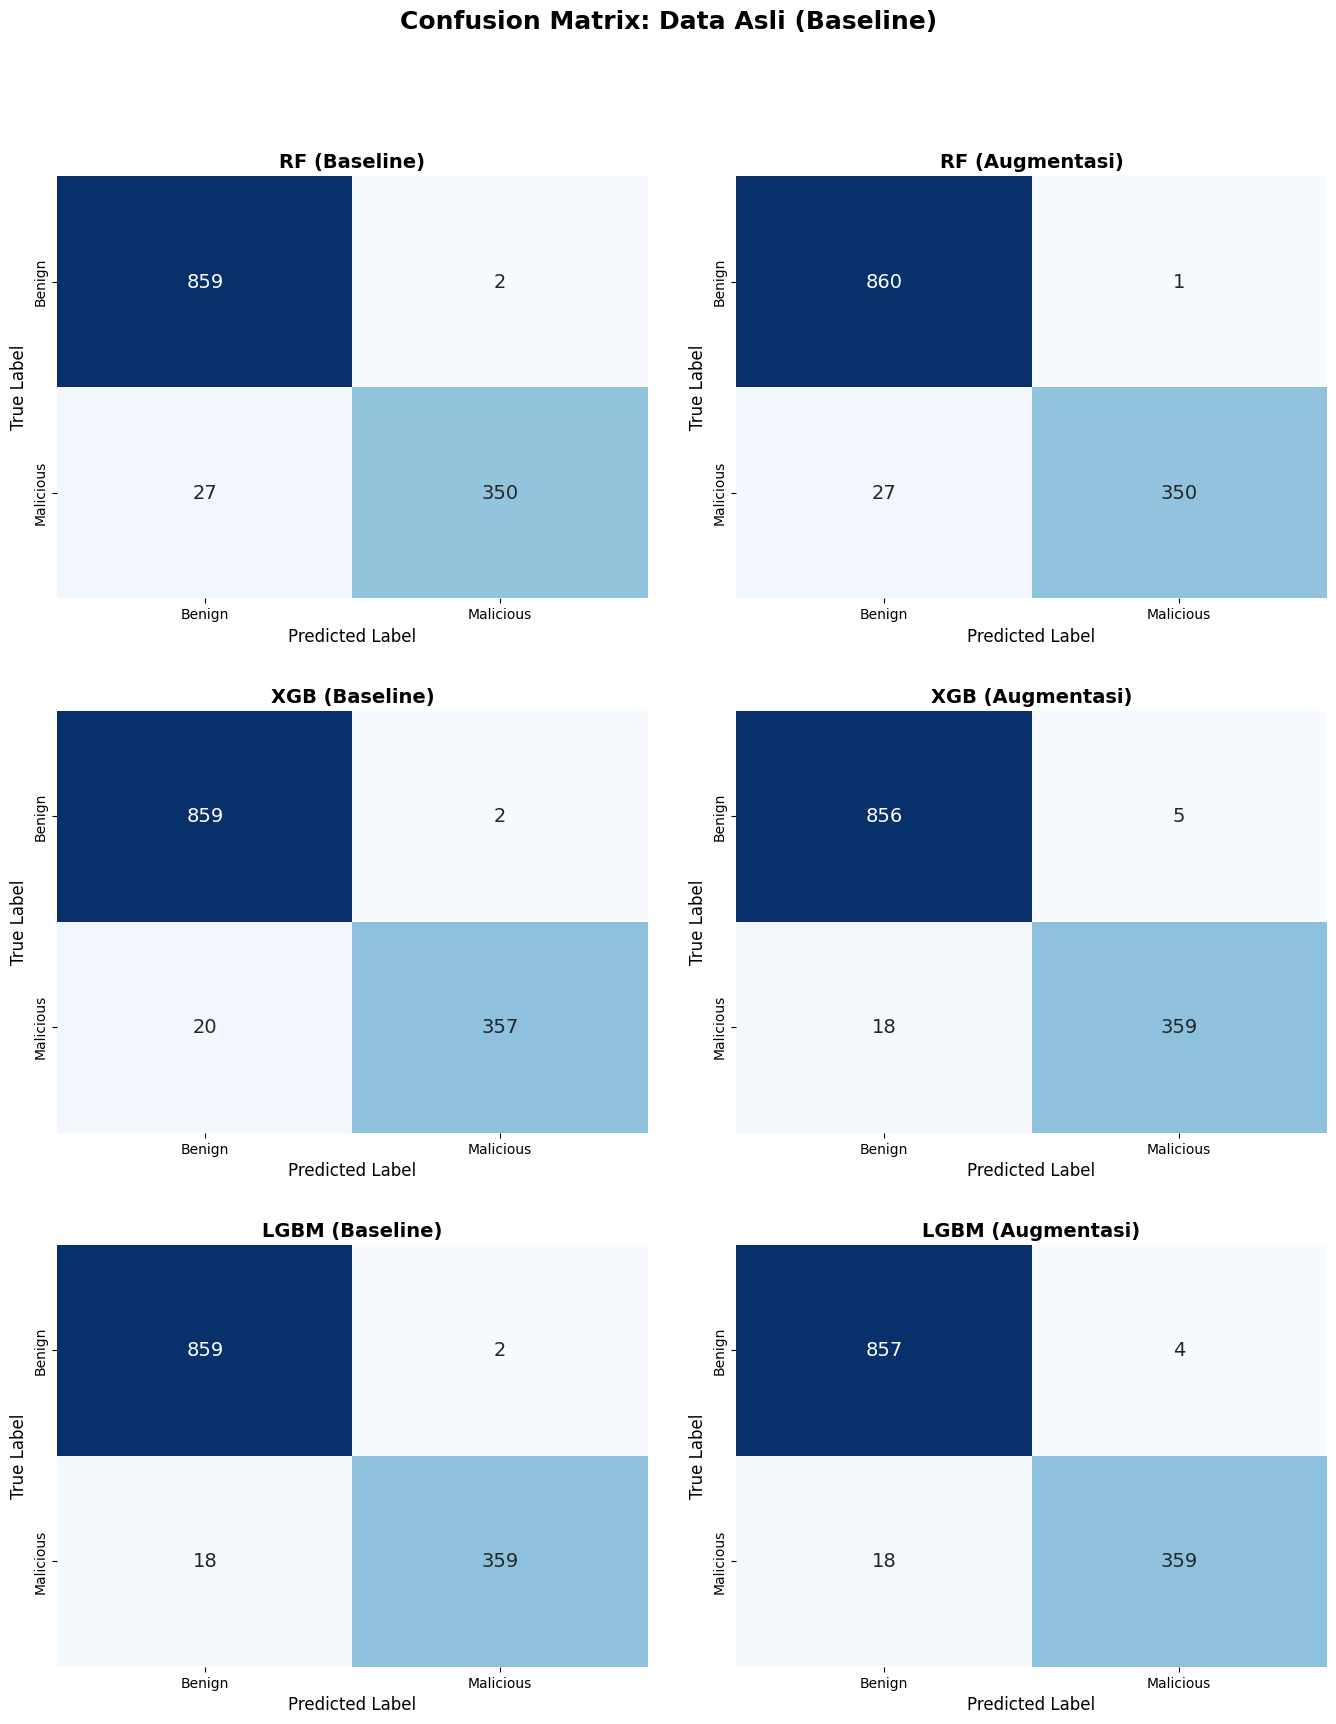

      -> Confusion Matrix disimpan di: cm_Data_Asli_Baseline_20260713_084059.png


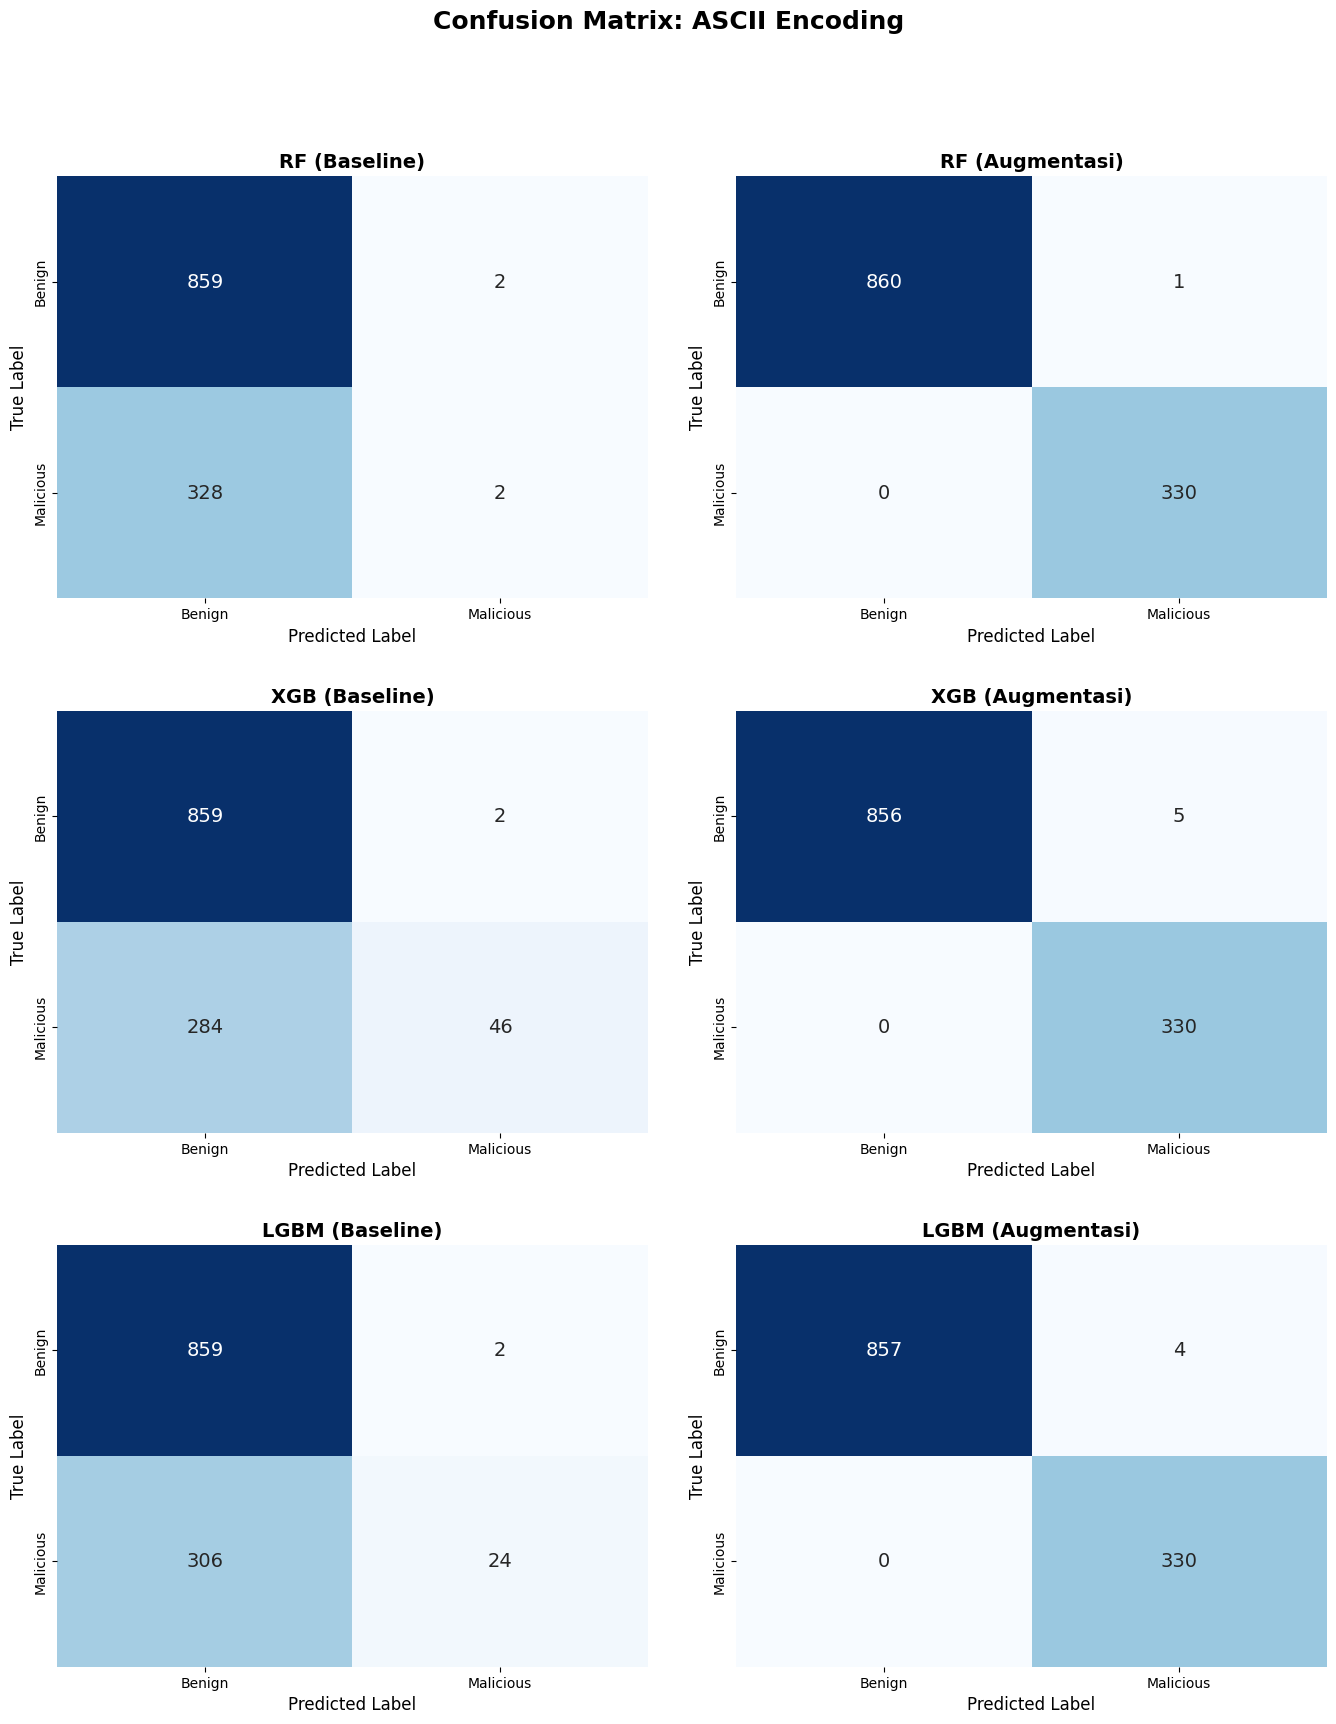

      -> Confusion Matrix disimpan di: cm_ASCII_Encoding_20260713_084059.png


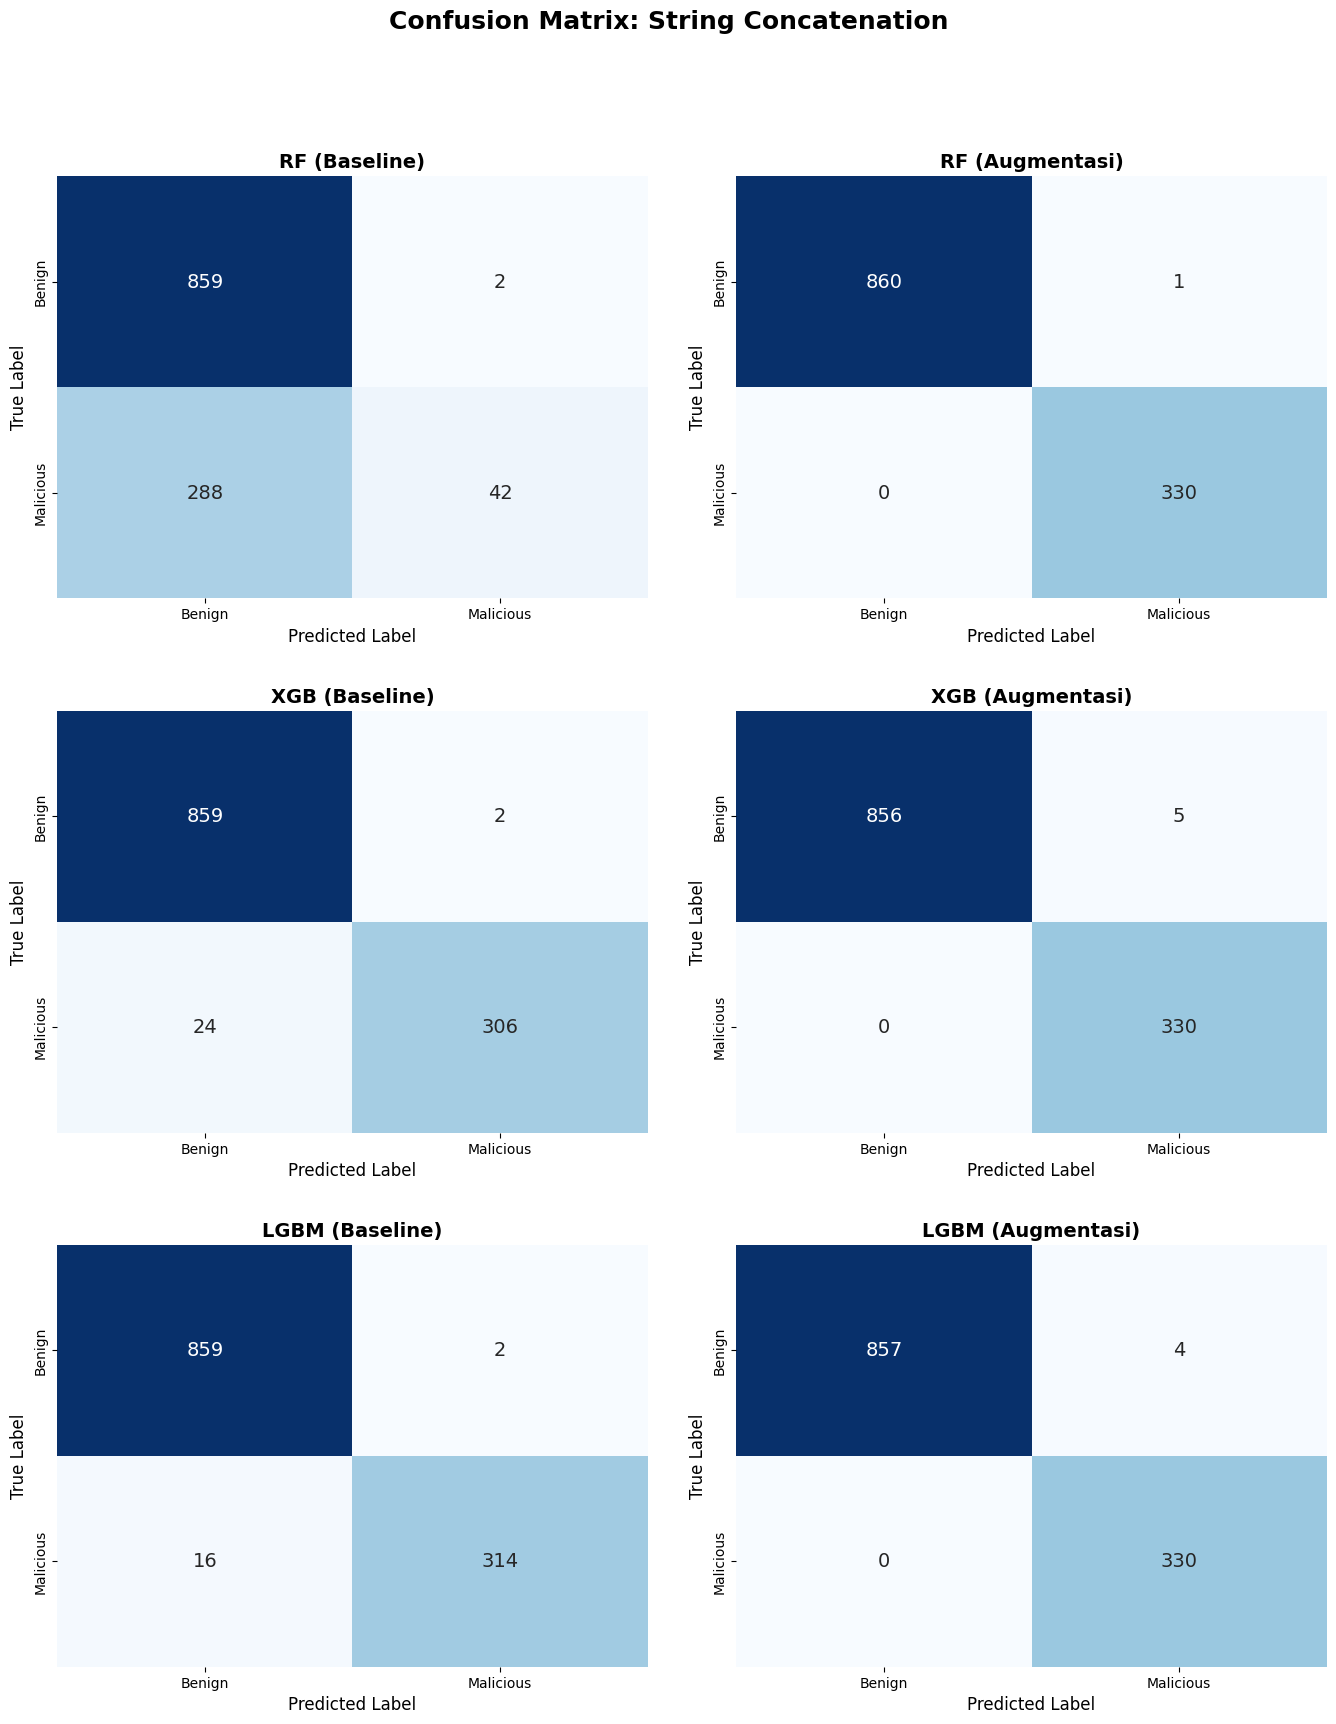

      -> Confusion Matrix disimpan di: cm_String_Concatenation_20260713_084059.png


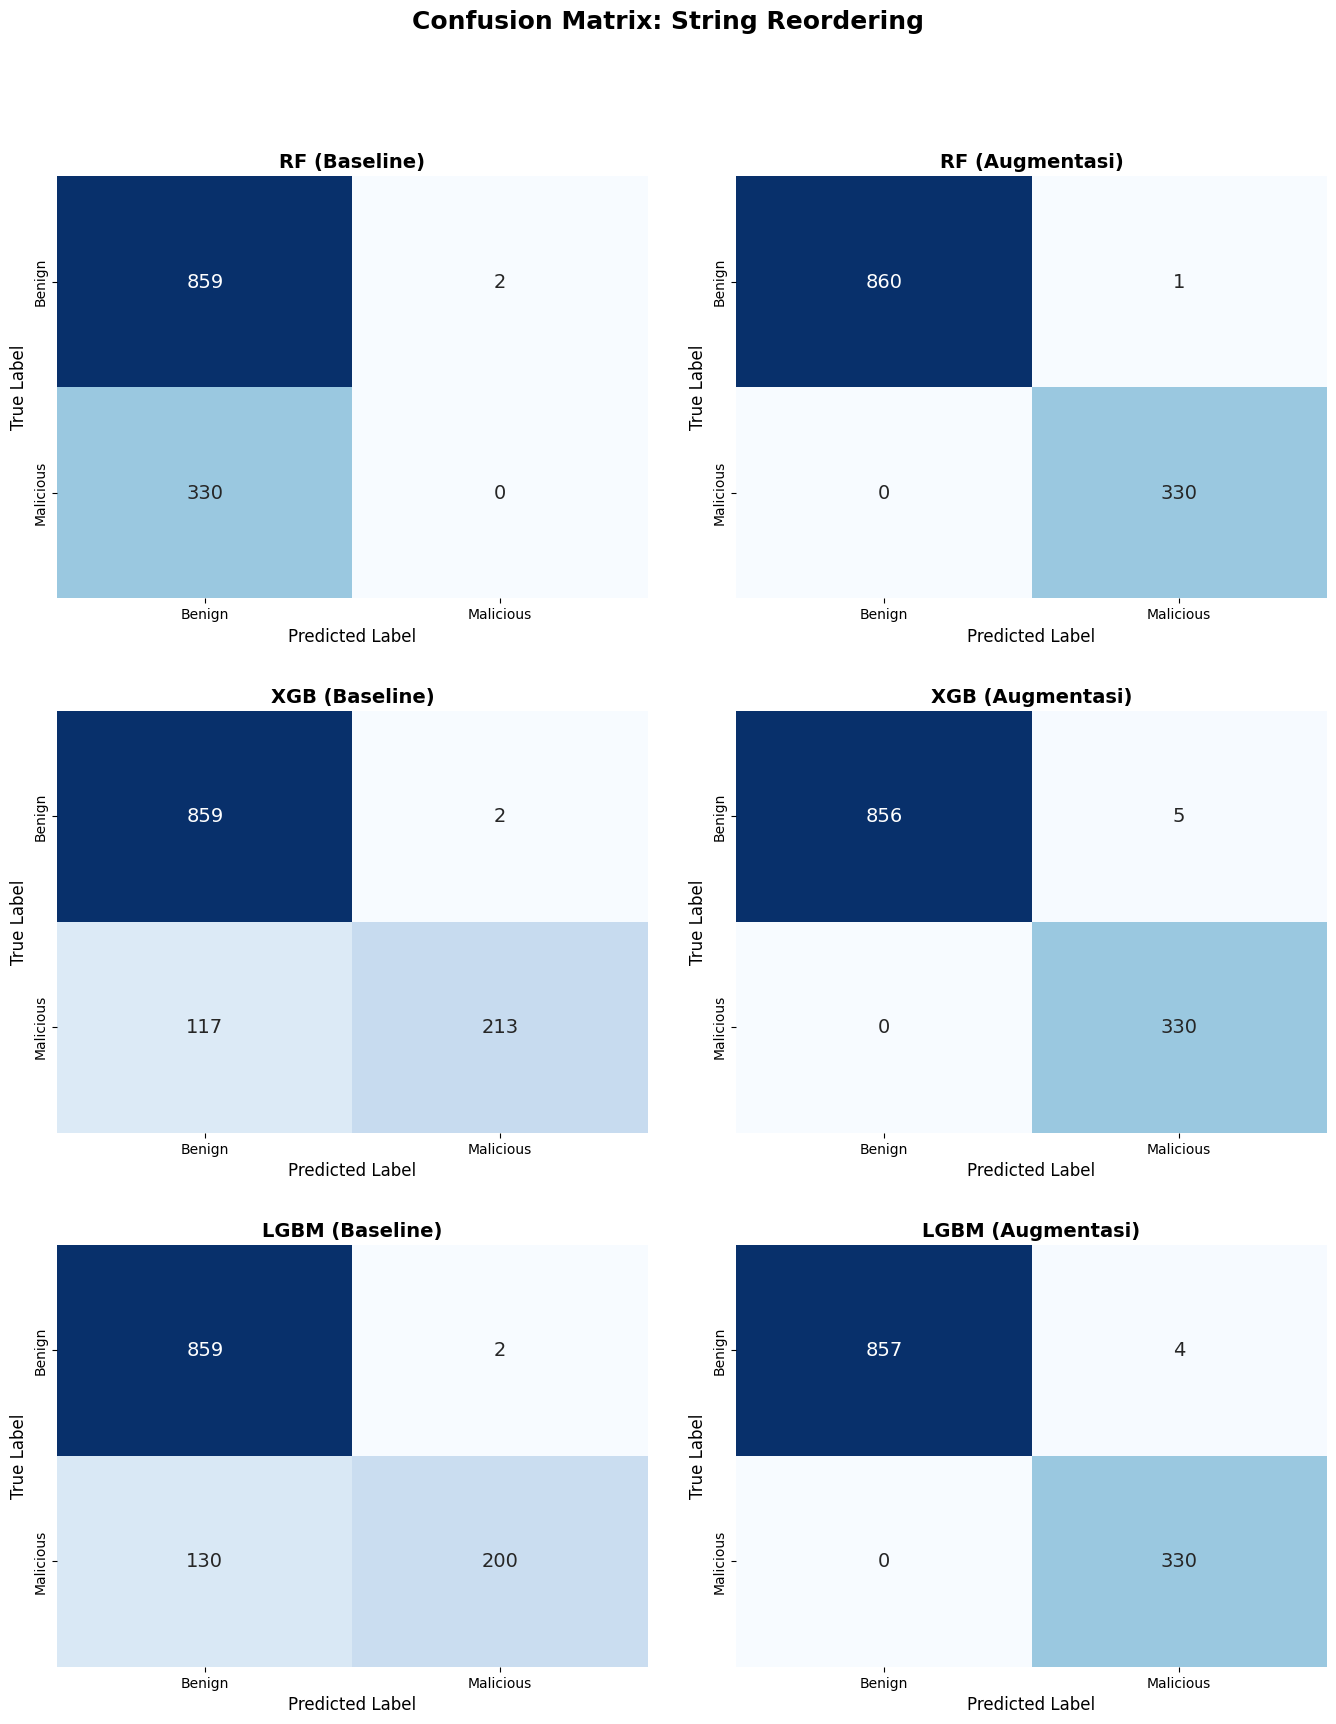

      -> Confusion Matrix disimpan di: cm_String_Reordering_20260713_084059.png


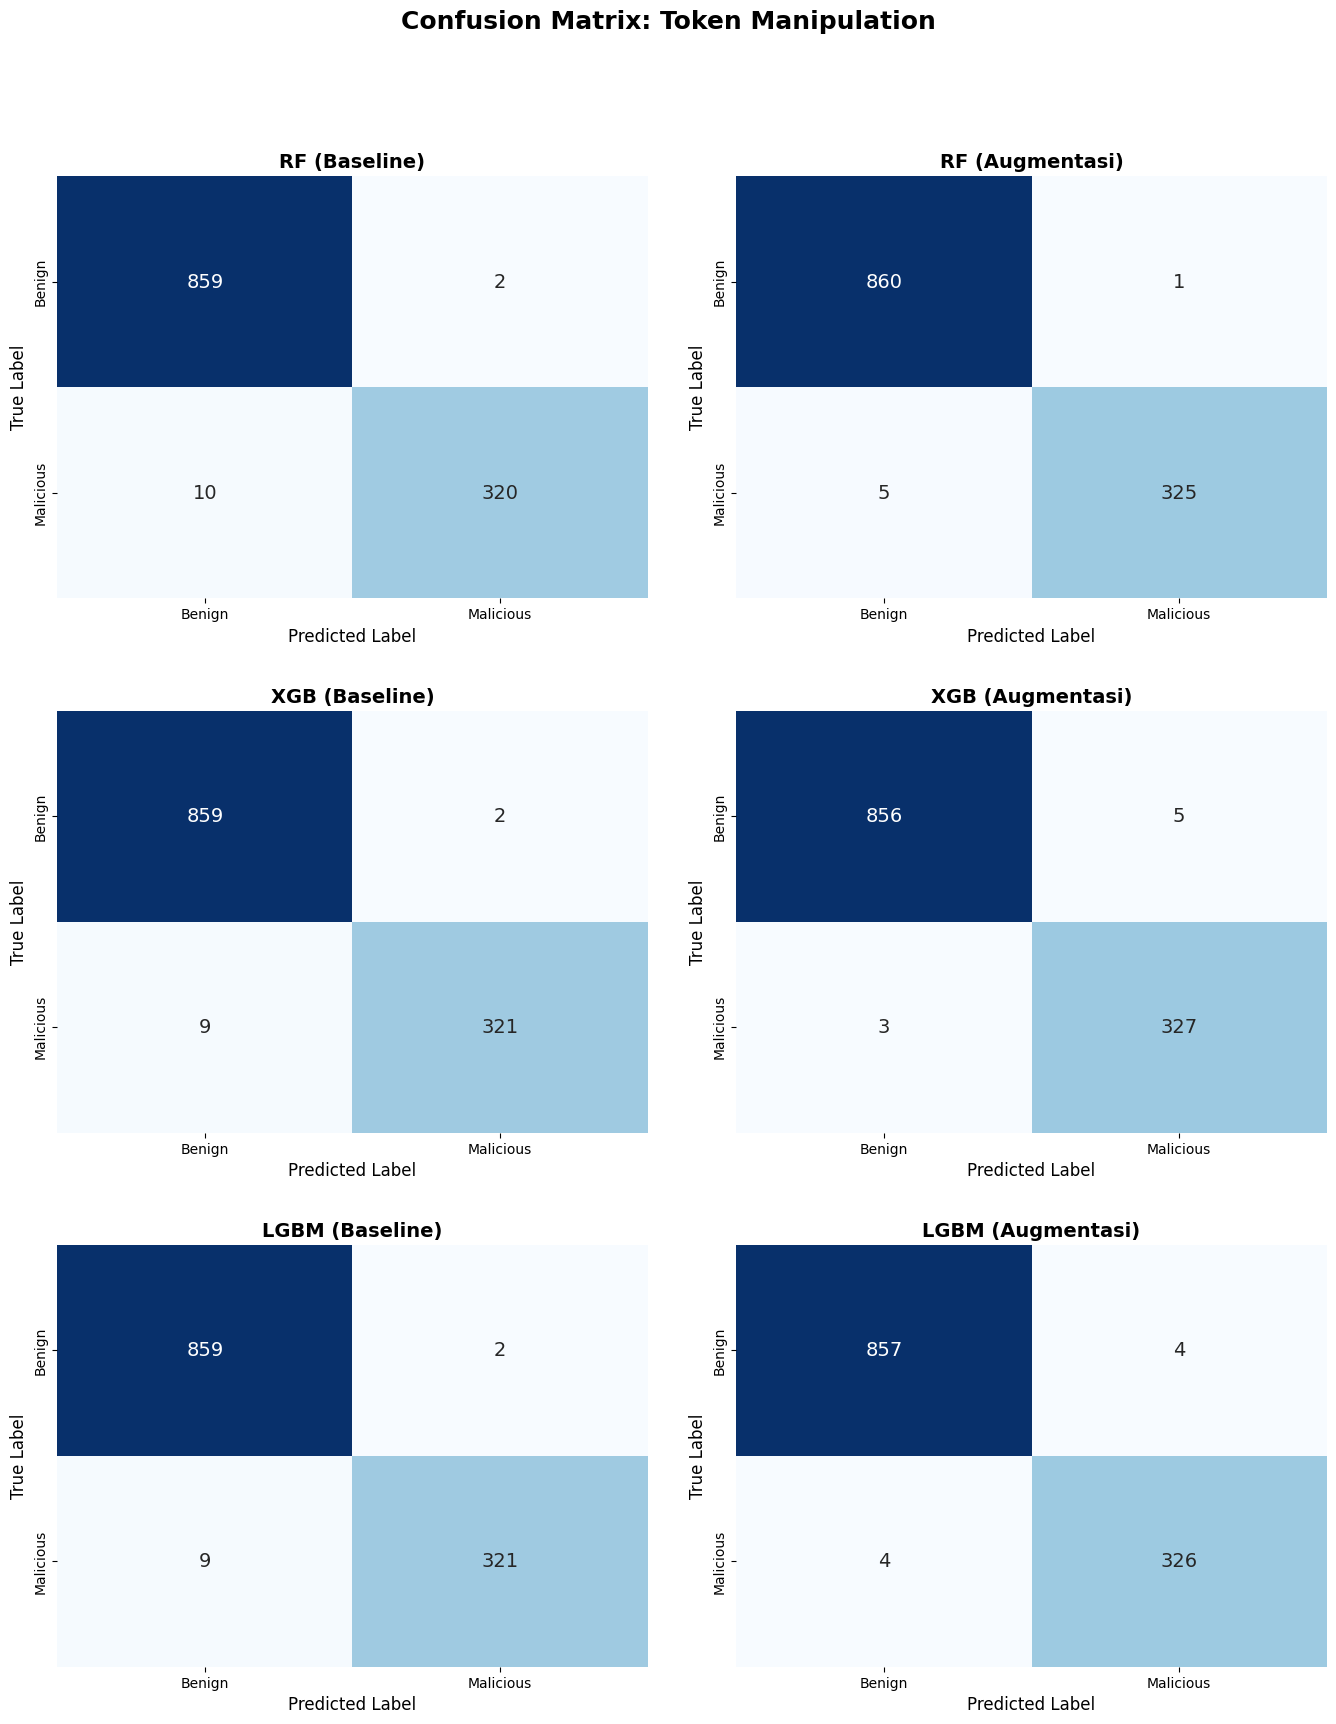

      -> Confusion Matrix disimpan di: cm_Token_Manipulation_20260713_084059.png

=== MENAMPILKAN BLOK VISUAL 1: GRUP KURVA ROC (LANDSCAPE) ===


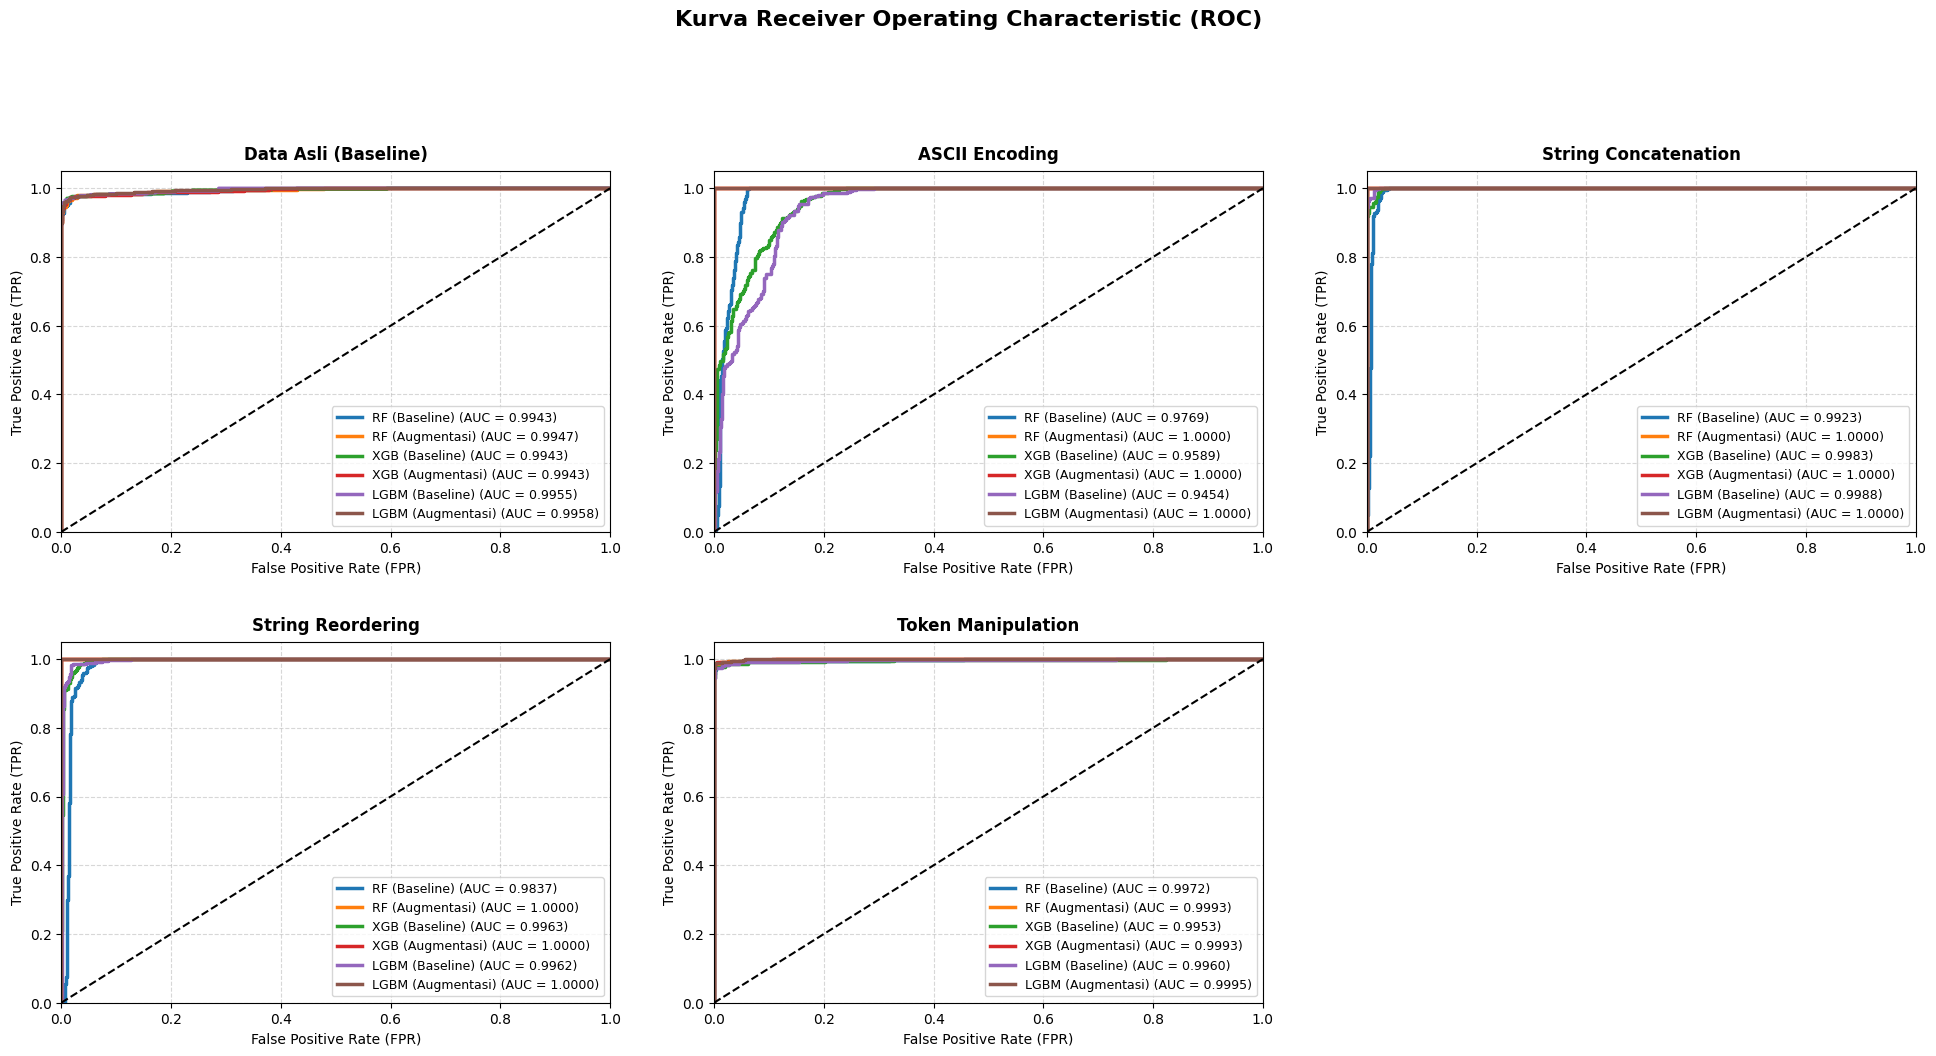

▶ [LANDSCAPE] Grup Visualisasi Kurva ROC Berhasil Di-render & Disimpan: roc_curve_all_20260713_084059.png

=== MENAMPILKAN BLOK VISUAL 2: GRUP KURVA PRECISION-RECALL (LANDSCAPE) ===


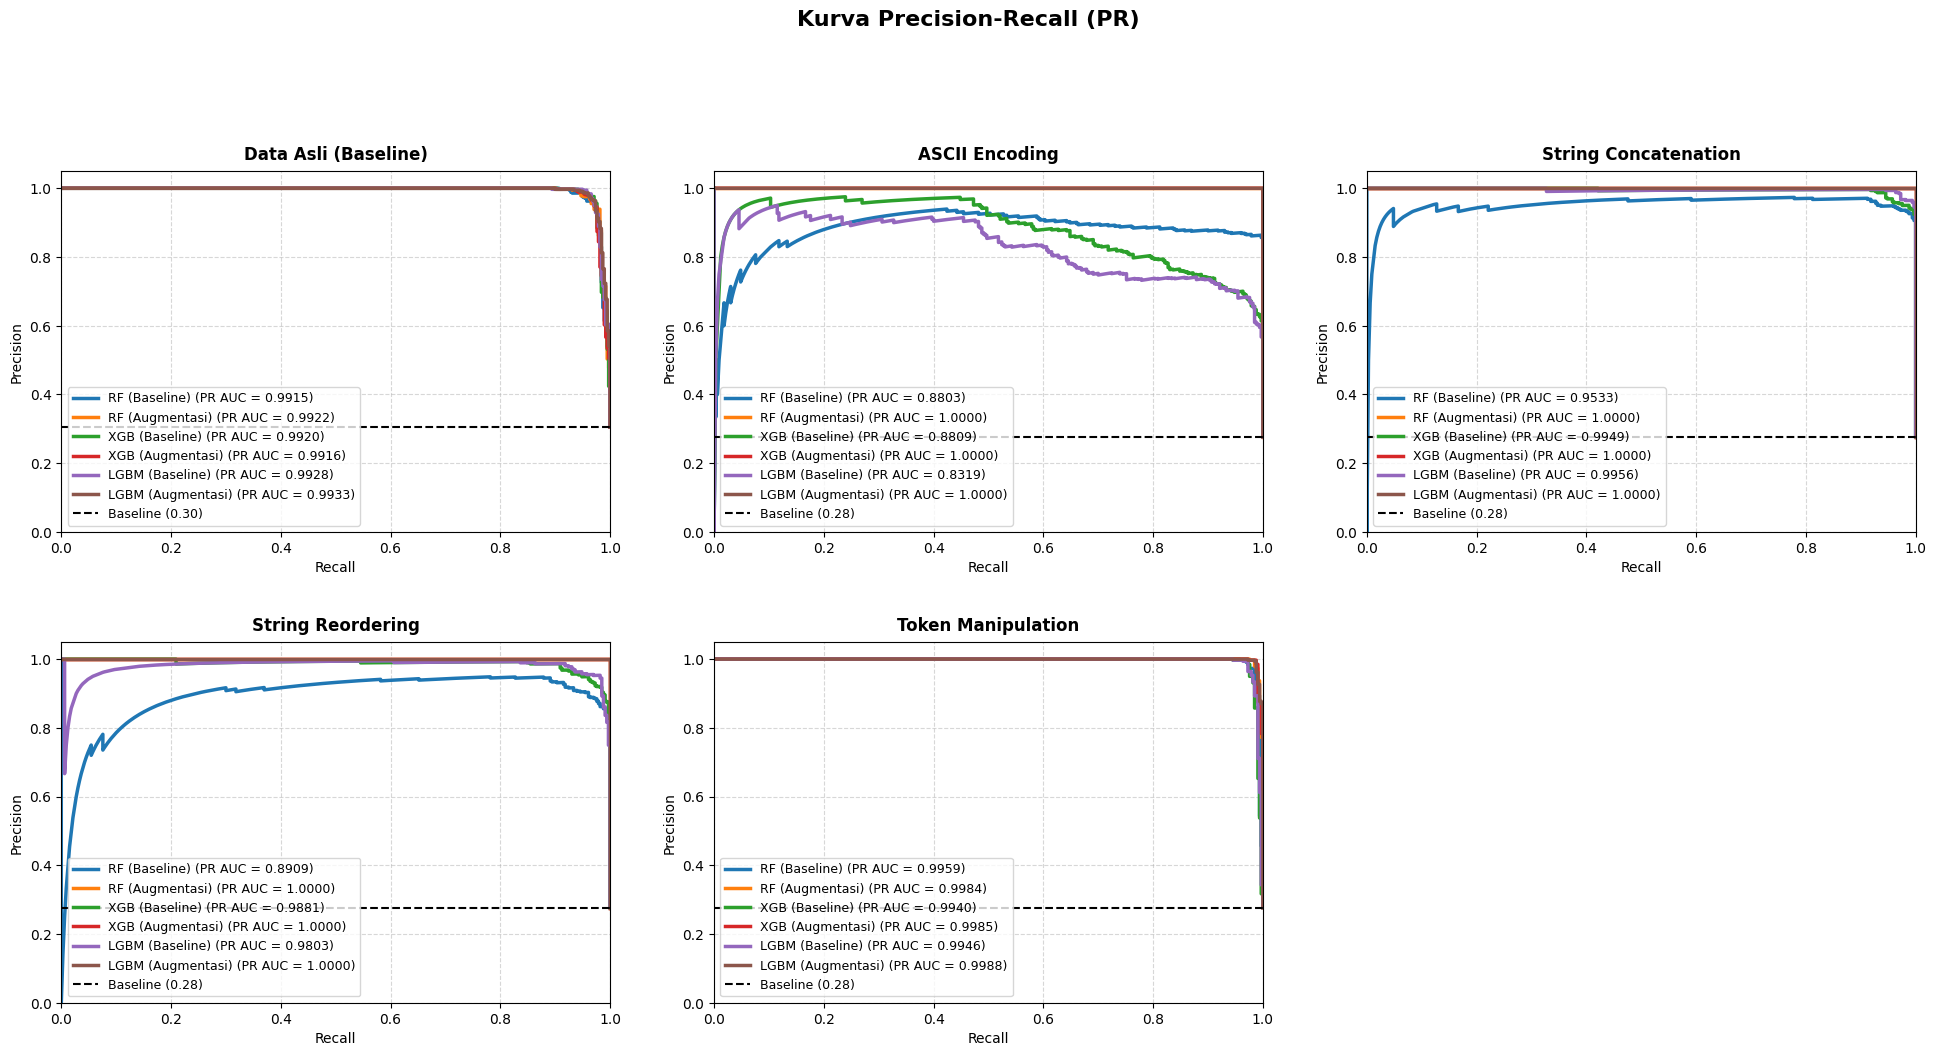

▶ [LANDSCAPE] Grup Visualisasi Kurva PR Berhasil Di-render & Disimpan: pr_curve_all_20260713_084059.png
⏹ EKSEKUSI EVALUASI SELESAI. Total Waktu: 0.33 Menit.


In [5]:
import time
from datetime import datetime

# =====================================================================
# EKSEKUSI PIPA EVALUASI UTAMA DENGAN PENGUKUR WAKTU & KALKULASI FPR/FNR
# =====================================================================
print("="*80)
print(f"▶ MULAI EKSEKUSI PIPELINE EVALUASI: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
waktu_mulai_evaluasi = time.time()

def load_latest_model(model_name: str, skenario: str) -> dict:
    """Mencari dan memuat model .joblib terbaru berdasarkan nama algoritma dan skenario."""
    pattern = str(MODEL_DIR / f"model_{model_name}_{skenario}_*.joblib")
    list_of_files = glob.glob(pattern)
    if not list_of_files:
        return None
    # Menemukan file yang paling akhir dikonstruksi
    latest_file = max(list_of_files, key=os.path.getmtime)
    return joblib.load(latest_file)

print("[*] Memuat seluruh model .joblib terbaru dari direktori output...")
loaded_models = {}
for m_name in ["RandomForest", "XGBoost", "LightGBM"]:
    for sken in ["Baseline", "Augmentasi"]:
        model_payload = load_latest_model(m_name, sken)
        if model_payload is not None:
            # Menyederhanakan singkatan agar grafik terlihat profesional dan rapi
            display_name = m_name.replace("RandomForest", "RF").replace("XGBoost", "XGB").replace("LightGBM", "LGBM")
            key_name = f"{display_name} ({sken})"
            loaded_models[key_name] = model_payload
            print(f"    - Berhasil memuat: {key_name}")

if not loaded_models:
    print("❌ [ERROR] Tidak ada berkas model .joblib ditemukan di folder output/models.")
else:
    print(f"✅ Sukses memuat {len(loaded_models)} arsitektur model untuk dievaluasi.")

    # Membaca dan Mengunci Data Benign Asli dari Skenario Baseline
    base_test_path = INPUT_DIR / BASELINE_TEST_CSV
    if not base_test_path.exists():
        print(f"❌ [ERROR] File induk data uji murni tidak ditemukan di: {base_test_path}")
    else:
        df_base_test = pd.read_csv(base_test_path).fillna(0)
        # Pisahkan komponen Benign murni (label == 0) untuk dicampur ke skenario obfuskasi
        df_benign_clean = df_base_test[df_base_test[LABEL_COL] == 0].copy()

        result_rows = []
        plot_data_registry = {}

        print("\n[*] Menjalankan Pengujian Komparatif Lintas Skenario Teknik...")
        
        for scenario_label, csv_name in TEST_FILES.items():
            csv_path = INPUT_DIR / csv_name
            if not csv_path.exists():
                print(f"[-] Lewati Skenario [{scenario_label}]: Berkas {csv_name} tidak ditemukan.")
                continue
                
            df_scenario_raw = pd.read_csv(csv_path).fillna(0)
            
            # Hubungkan Malicious teknik dengan Benign murni asli
            if scenario_label == "Data Asli (Baseline)":
                df_test_final = df_scenario_raw.copy()
            else:
                df_malicious_obf = df_scenario_raw[df_scenario_raw[LABEL_COL] == 1].copy()
                df_test_final = pd.concat([df_benign_clean, df_malicious_obf]).sample(frac=1, random_state=42).reset_index(drop=True)
            
            models_data = {}
            
            # Iterasi prediksi untuk setiap arsitektur model
            for model_display, payload in loaded_models.items():
                model = payload["model"]
                feature_cols = payload["feature_cols"]
                
                # Penanganan darurat jika terdapat kolom fitur yang tidak konsisten
                for col in feature_cols:
                    if col not in df_test_final.columns:
                        df_test_final[col] = 0
                        
                X_test = df_test_final[feature_cols]
                y_test = df_test_final[LABEL_COL]
                
                # Kalkulasi nilai prediksi kelas dan probabilitas skor
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
                
                # [DIPERBARUI]: Kalkulasi FPR & FNR dari Confusion Matrix
                cm = confusion_matrix(y_test, y_pred)
                if cm.shape == (2, 2):
                    tn, fp, fn, tp = cm.ravel()
                    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
                else:
                    fpr, fnr = 0.0, 0.0
                
                # [DIPERBARUI]: Rekam metrik tambahan FPR dan FNR ke dalam database baris
                result_rows.append({
                    "Skenario Uji"  : scenario_label,
                    "Model-Skenario": model_display,
                    "Accuracy"      : accuracy_score(y_test, y_pred),
                    "Precision"     : precision_score(y_test, y_pred, zero_division=0),
                    "Recall"        : recall_score(y_test, y_pred, zero_division=0),
                    "F1-Score"      : f1_score(y_test, y_pred, zero_division=0),
                    "FPR"           : fpr,
                    "FNR"           : fnr,
                    "ROC AUC"       : roc_auc_score(y_test, y_proba),
                    "PR AUC"        : average_precision_score(y_test, y_proba)
                })
                
                models_data[model_display] = {
                    'cm': cm,
                    'y_true': y_test,
                    'y_pred': y_pred,
                    'y_proba': y_proba
                }
                
            plot_data_registry[scenario_label] = models_data

        # 1. Cetak Laporan Output Berbentuk Tabel Teks & CSV Otomatis
        _print_comparison_table_formatted(result_rows, waktu_sekarang)
        
        # 2. Render Diagram Confusion Matrix Berurutan
        print("\n=== VISUALISASI CONFUSION MATRIX INLINE ===")
        for scenario_label, models_data in plot_data_registry.items():
            if models_data:
                _plot_combined_confusion_matrix(scenario_label, models_data, waktu_sekarang)
                
        # 3. Visualisasi Blok Kelompok Kurva ROC (Format Melebar / Landscape)
        print("\n=== MENAMPILKAN BLOK VISUAL 1: GRUP KURVA ROC (LANDSCAPE) ===")
        _plot_roc_curves_landscape_grid(plot_data_registry, waktu_sekarang)
        
        # 4. Visualisasi Blok Kelompok Kurva Precision-Recall (Format Melebar / Landscape)
        print("\n=== MENAMPILKAN BLOK VISUAL 2: GRUP KURVA PRECISION-RECALL (LANDSCAPE) ===")
        _plot_pr_curves_landscape_grid(plot_data_registry, waktu_sekarang)

# Kalkulasi durasi akhir pengujian
durasi_evaluasi = (time.time() - waktu_mulai_evaluasi) / 60
print("="*80)
print(f"⏹ EKSEKUSI EVALUASI SELESAI. Total Waktu: {durasi_evaluasi:.2f} Menit.")
print("="*80)